# Step 1: Feature Extraction

In [3]:
import os
import cv2
import numpy as np

# Function to extract 24-dimensional color histogram features from a single patch
def extract_patch_histogram(patch, bins=(8, 8, 8)):
    # Extract 8-bin color histograms for R, G, B channels
    hist_r = cv2.calcHist([patch], [0], None, [bins[0]], [0, 256]).flatten()  # Red channel
    hist_g = cv2.calcHist([patch], [1], None, [bins[1]], [0, 256]).flatten()  # Green channel
    hist_b = cv2.calcHist([patch], [2], None, [bins[2]], [0, 256]).flatten()  # Blue channel
    
    # Normalize histograms
    hist_r /= np.sum(hist_r)
    hist_g /= np.sum(hist_g)
    hist_b /= np.sum(hist_b)
    
    # Concatenate R, G, B histograms into a 24-dimensional vector
    feature_vector = np.concatenate([hist_r, hist_g, hist_b])
    return feature_vector

# Function to divide image into 32x32 patches and extract features from each patch
def extract_image_features(image, patch_size=(32, 32), bins=(8, 8, 8)):
    img_h, img_w, _ = image.shape
    all_patches_features = []
    
    # Extract patches
    for i in range(0, img_h, patch_size[0]):
        for j in range(0, img_w, patch_size[1]):
            patch = image[i:i+patch_size[0], j:j+patch_size[1]]
            if patch.shape[0] == patch_size[0] and patch.shape[1] == patch_size[1]:
                patch_features = extract_patch_histogram(patch, bins)
                all_patches_features.append(patch_features)
    
    return np.array(all_patches_features)

# Function to save feature vectors to a file
def save_feature_vectors(feature_vectors, save_path):
    np.save(save_path, feature_vectors)

# Process the images in the 'botanical_garden', 'bus_interior', and 'elevator_shaft' classes for both training and test datasets
def process_images_from_folder(folder_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for class_folder in os.listdir(folder_path):
        class_folder_path = os.path.join(folder_path, class_folder)
        output_class_folder = os.path.join(output_folder, class_folder)
        if not os.path.exists(output_class_folder):
            os.makedirs(output_class_folder)
        
        for image_name in os.listdir(class_folder_path):
            image_path = os.path.join(class_folder_path, image_name)
            image = cv2.imread(image_path)
            if image is not None:
                features = extract_image_features(image)
                save_path = os.path.join(output_class_folder, f"{image_name.split('.')[0]}_features.npy")
                save_feature_vectors(features, save_path)
                print(f"Processed and saved features for {image_name}")

# Example usage for processing train and test datasets
train_folder = r'3-class-scene-image-dataset\train'  # Path to the train dataset
test_folder = r'3-class-scene-image-dataset\test'    # Path to the test dataset
output_train_features = r'3-class-scene-image-dataset\output_train_feature'  # Folder to save train features
output_test_features = r'3-class-scene-image-dataset\output_test_feature'    # Folder to save test features

# Process training set
print("Processing training images...")
process_images_from_folder(train_folder, output_train_features)

# Process test set
print("Processing test images...")
process_images_from_folder(test_folder, output_test_features)


Processing training images...
Processed and saved features for sun_aagvwgntclshghai.jpg
Processed and saved features for sun_aamlzecjkxlnoedl.jpg
Processed and saved features for sun_aarrlvxxrjxftsuu.jpg
Processed and saved features for sun_abjxfjcrqxjhbkhi.jpg
Processed and saved features for sun_abybmfbnmlztrjpm.jpg
Processed and saved features for sun_acrbvetgiwtbvpid.jpg
Processed and saved features for sun_acrvwdwcnqgbvcbi.jpg
Processed and saved features for sun_adlsavfxcjkctdfu.jpg
Processed and saved features for sun_aeylitslkauqmnqw.jpg
Processed and saved features for sun_afqgbxrmirjsvmid.jpg
Processed and saved features for sun_afxnftrhigdckaaa.jpg
Processed and saved features for sun_aghkmbqrsfmpshxw.jpg
Processed and saved features for sun_aglxrcfjrogfzdhm.jpg
Processed and saved features for sun_ahtzdwjqixilslrl.jpg
Processed and saved features for sun_airytsbhvjoeuqnk.jpg
Processed and saved features for sun_aiuhwofaknavsqzr.jpg
Processed and saved features for sun_akbyd

# Step 2: Build the Bayes Classifier Using GMM

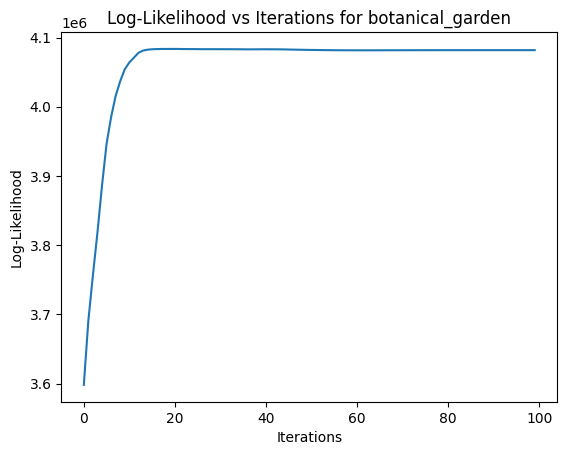

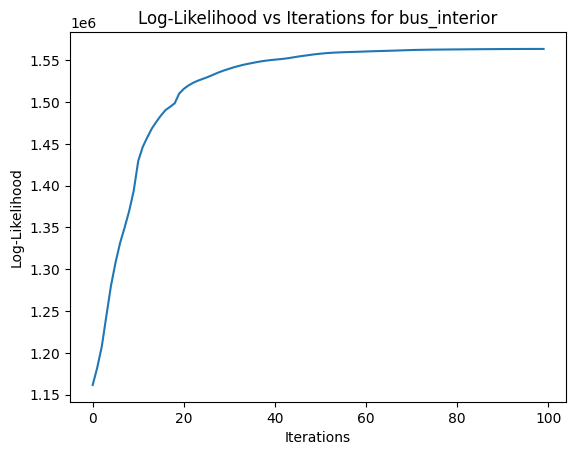

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# K-means implementation for initializing GMM
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    clusters = []
    for x in X:
        distances = [np.linalg.norm(x - centroid) for centroid in centroids]
        clusters.append(np.argmin(distances))
    return np.array(clusters)

def update_centroids(X, clusters, k):
    new_centroids = []
    for i in range(k):
        cluster_points = X[clusters == i]
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            new_centroids.append(np.random.rand(X.shape[1]))  # Reinitialize if cluster is empty
    return np.array(new_centroids)

def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, k)
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return centroids, clusters

# GMM implementation using K-means initialization
def gaussian_pdf(x, mean, cov):
    n = len(x)
    cov_det = np.linalg.det(cov)
    if cov_det <= 0:
        cov_det = 1e-6  # Handle singular matrix case
    cov_inv = np.linalg.inv(cov + np.eye(len(cov)) * 1e-6)  # Add regularization
    diff = x - mean
    exponent = -0.5 * np.dot(diff.T, np.dot(cov_inv, diff))
    return np.exp(exponent) / np.sqrt((2 * np.pi)**n * cov_det)

def expectation_step(X, means, covariances, weights):
    n, k = X.shape[0], len(means)
    responsibilities = np.zeros((n, k))
    for i in range(k):
        for j in range(n):
            responsibilities[j, i] = weights[i] * gaussian_pdf(X[j], means[i], covariances[i])
    responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
    responsibilities_sum[responsibilities_sum == 0] = 1e-6  # Avoid divide by zero
    responsibilities /= responsibilities_sum
    return responsibilities

def maximization_step(X, responsibilities):
    n, d = X.shape
    k = responsibilities.shape[1]
    weights = responsibilities.sum(axis=0) / n
    means = np.dot(responsibilities.T, X) / responsibilities.sum(axis=0)[:, None]
    covariances = []
    for i in range(k):
        diff = X - means[i]
        covariances.append(np.dot((responsibilities[:, i] * diff.T), diff) / responsibilities[:, i].sum())
        covariances[i] += np.eye(d) * 1e-6  # Regularize covariance
    return means, covariances, weights

def gmm_em(X, k, max_iters=100, tol=1e-6):
    # Initialize GMM parameters using K-means
    means, clusters = kmeans(X, k)
    covariances = [np.cov(X[clusters == i].T) + np.eye(X.shape[1]) * 1e-6 for i in range(k)]
    weights = np.array([np.mean(clusters == i) for i in range(k)])
    
    log_likelihoods = []
    
    for iteration in range(max_iters):
        responsibilities = expectation_step(X, means, covariances, weights)
        means, covariances, weights = maximization_step(X, responsibilities)
        
        log_likelihood = np.sum([
            np.log(np.maximum(np.sum([weights[i] * gaussian_pdf(X[j], means[i], covariances[i]) for i in range(k)]), 1e-6))
            for j in range(len(X))
        ])
        log_likelihoods.append(log_likelihood)
        
        if len(log_likelihoods) > 1 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
    
    return means, covariances, weights, log_likelihoods

# Function to classify new data points using trained GMM
def classify_gmm(x, means, covariances, weights):
    likelihoods = [weights[i] * gaussian_pdf(x, means[i], covariances[i]) for i in range(len(means))]
    return np.argmax(likelihoods)

# Function to evaluate model on test data
def evaluate_gmm(test_features, means, covariances, weights, label):
    y_true = []
    y_pred = []
    
    for feature in test_features:
        predicted_class = classify_gmm(feature, means, covariances, weights)
        y_true.append(label)  # Assign the true class label
        y_pred.append(predicted_class)
    
    return y_true, y_pred

# Training and evaluation for all classes
def train_and_evaluate_gmm(train_features_path, test_features_path, k=4):
    label_dict = {'botanical_garden': 0, 'bus_interior': 1, 'elevator_shaft': 2}
    
    # Train GMM for each class
    gmm_models = {}
    log_likelihoods_per_class = {}
    
    for class_name in label_dict:
        class_label = label_dict[class_name]
        class_folder = os.path.join(train_features_path, class_name)
        features = np.vstack([np.load(os.path.join(class_folder, f)) for f in os.listdir(class_folder)])
        
        # Train GMM using EM
        means, covariances, weights, log_likelihoods = gmm_em(features, k)
        gmm_models[class_label] = (means, covariances, weights)
        log_likelihoods_per_class[class_label] = log_likelihoods
        
        # Plot log-likelihood vs iteration for this class
        plt.plot(log_likelihoods)
        plt.title(f'Log-Likelihood vs Iterations for {class_name}')
        plt.xlabel('Iterations')
        plt.ylabel('Log-Likelihood')
        plt.show()
    
    # Evaluate on test data
    y_true = []
    y_pred = []
    
    for class_name in label_dict:
        class_label = label_dict[class_name]
        class_folder = os.path.join(test_features_path, class_name)
        test_features = np.vstack([np.load(os.path.join(class_folder, f)) for f in os.listdir(class_folder)])
        
        true_labels, predicted_labels = evaluate_gmm(test_features, *gmm_models[class_label], class_label)
        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)
    
    return np.array(y_true), np.array(y_pred)

# Metrics calculation and confusion matrix
def calculate_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    accuracy = np.mean(y_true == y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Example usage
train_features_path = r'3-class-scene-image-dataset\output_train_feature'  # Folder where the train features are saved
test_features_path = r'3-class-scene-image-dataset\output_test_feature'    # Folder where the test features are saved

# Train and evaluate GMM
y_true, y_pred = train_and_evaluate_gmm(train_features_path, test_features_path)

# Calculate performance metrics
calculate_metrics(y_true, y_pred)
